In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from category_encoders import TargetEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report

import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [2]:
# Cambiar ruta del dataset, ya que de forma parcial tira error

df = pd.read_csv(r"..\csv\cleaned_data.csv")
print("Forma del dataset:", df.shape)
print("\nPrimeras filas:")
df.head()

Forma del dataset: (30552, 14)

Primeras filas:


,Campaña,Pedido,Zona,Dirección entrega,Telefono,Barrio,Ciudad,Fecha recibo LD,Fecha reparto,Fecha entrega,Transportador,Estado,horas_entrega,umbral
0,202407,37087842,601,KR 47A 48 39- TEL 0-3143423923,0-3143423923,CORDOBA,CALI (VALLE),2024-04-27 19:07:31,2024-04-29 10:43:16,2024-04-29 22:08:43,CBZ922,A TIEMPO,11.424167,24
1,202407,37093297,580,CR 1H NORTE 77-10 SEGUNDO PISO- TEL 0-3154678944,0-3154678944,COMFENALCO,CALI (VALLE),2024-04-27 19:04:43,2024-04-28 10:24:04,2024-04-28 16:40:32,TZY274,A TIEMPO,6.274444,24
2,202407,37098642,594,CALLETERSERA SN124- TEL 0-3016931064,0-3016931064,PROVIVIENDA,DAGUA (VALLE),2024-04-28 20:40:40,2024-04-29 11:18:40,2024-04-30 12:00:25,TZN919,A TIEMPO,24.695833,48
3,202407,37105003,603,CL 18 A 9 A 11 PISO NO 1- TEL 0-3136142043,0-3136142043,CARLOS GUZMAN,PUERTO TEJADA (CAUCA),2024-05-04 09:36:18,2024-05-04 13:10:03,2024-05-05 23:00:44,CEN356,A TIEMPO,33.844722,48
4,202407,37111291,603,KR 18 15 A 40- TEL 0-3125418458,0-3125418458,LA SAMARIA,SANTANDER DE QUILICHAO (CAUCA),2024-05-04 09:18:31,2024-05-06 08:39:17,2024-05-06 22:00:29,TZY274,A TIEMPO,13.353333,48


## Seleccion y arreglo de Features

In [3]:
columnas_usar = ['Zona', 'Barrio', 'Ciudad', 'Fecha recibo LD', 'Fecha reparto', 
                 'Fecha entrega', 'Transportador', 'Estado']

df_modelo = df[columnas_usar].copy()
print("Columnas a usar:", columnas_usar)
print("\nTipos de datos:")
print(df_modelo.dtypes)
print("\nValores únicos por columna:")
for col in df_modelo.columns:
    print(f"{col}: {df_modelo[col].nunique()} valores únicos")

Columnas a usar: ['Zona', 'Barrio', 'Ciudad', 'Fecha recibo LD', 'Fecha reparto', 'Fecha entrega', 'Transportador', 'Estado']

Tipos de datos:
Zona               str
Barrio             str
Ciudad             str
Fecha recibo LD    str
Fecha reparto      str
Fecha entrega      str
Transportador      str
Estado             str
dtype: object

Valores únicos por columna:
Zona: 9 valores únicos
Barrio: 709 valores únicos
Ciudad: 36 valores únicos
Fecha recibo LD: 28095 valores únicos
Fecha reparto: 30505 valores únicos
Fecha entrega: 30415 valores únicos
Transportador: 24 valores únicos
Estado: 2 valores únicos


In [4]:
# Convertir fechas a datetime
df_modelo['Fecha recibo LD'] = pd.to_datetime(df_modelo['Fecha recibo LD'])

# Extraer características de fechas
df_modelo['Recibo_DayOfWeek'] = df_modelo['Fecha recibo LD'].dt.dayofweek
df_modelo['Recibo_Month'] = df_modelo['Fecha recibo LD'].dt.month
df_modelo['Recibo_Day'] = df_modelo['Fecha recibo LD'].dt.day

In [5]:
# Codificar variable objetivo ANTES del split
le_estado = LabelEncoder()
y = le_estado.fit_transform(df_modelo['Estado'])
print("Clases codificadas:")
for clase, codigo in zip(le_estado.classes_, le_estado.transform(le_estado.classes_)):
    print(f"  {clase}: {codigo}")
print(f"\nDistribución de clases:")
print(pd.Series(y).value_counts())

Clases codificadas:
  A TIEMPO: 0
  TARDE: 1

Distribución de clases:
0    23471
1     7081
Name: count, dtype: int64


## Split train-test

In [6]:
# Split train-test
X_train, X_test, y_train, y_test = train_test_split(
    df_modelo, y, test_size=0.3, random_state=42, stratify=y
)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (21386, 11)
X_test shape: (9166, 11)


## One Hot Encoding

In [7]:
# One-Hot Encoding para Transportador (después del split)
transportador_train = pd.get_dummies(X_train['Transportador'], prefix='Transportador', drop_first=True)
transportador_test = pd.get_dummies(X_test['Transportador'], prefix='Transportador', drop_first=True)

# Alinear columnas de test con train
for col in transportador_train.columns:
    if col not in transportador_test.columns:
        transportador_test[col] = 0
transportador_test = transportador_test[transportador_train.columns]

# Target Encoding para Barrio (fit en train, transform en test)
be = TargetEncoder(cols=['Barrio'])
barrio_train = be.fit_transform(X_train[['Barrio']], y_train)
barrio_test = be.transform(X_test[['Barrio']])
barrio_train.columns = ['Barrio_TargetEncoded']
barrio_test.columns = ['Barrio_TargetEncoded']

# Target Encoding para Ciudad (fit en train, transform en test)
te = TargetEncoder(cols=['Ciudad'])
ciudad_train = te.fit_transform(X_train[['Ciudad']], y_train)
ciudad_test = te.transform(X_test[['Ciudad']])
ciudad_train.columns = ['Ciudad_TargetEncoded']
ciudad_test.columns = ['Ciudad_TargetEncoded']

print(f"Transportador features: {transportador_train.shape[1]}")
print(f"Barrio features: {barrio_train.shape[1]}")
print(f"Ciudad features: {ciudad_train.shape[1]}")

Transportador features: 23
Barrio features: 1
Ciudad features: 1


## Label Encoding

In [8]:
# Label Encoding para Zona (fit en train, transform en test)
le_zona = LabelEncoder()
zona_train = le_zona.fit_transform(X_train['Zona']).reshape(-1, 1)
zona_test = le_zona.transform(X_test['Zona']).reshape(-1, 1)

# Resetear índices para evitar problemas al concatenar
X_train_reset = X_train.reset_index(drop=True)
X_test_reset = X_test.reset_index(drop=True)

# Construir matriz de features para train
X_train_features = pd.concat([
    pd.DataFrame(zona_train, columns=['Zona']),
    barrio_train.reset_index(drop=True),
    ciudad_train.reset_index(drop=True),
    transportador_train.reset_index(drop=True),
    X_train_reset[['Recibo_DayOfWeek', 'Recibo_Month', 'Recibo_Day']].reset_index(drop=True)
], axis=1)

# Construir matriz de features para test
X_test_features = pd.concat([
    pd.DataFrame(zona_test, columns=['Zona']),
    barrio_test.reset_index(drop=True),
    ciudad_test.reset_index(drop=True),
    transportador_test.reset_index(drop=True),
    X_test_reset[['Recibo_DayOfWeek', 'Recibo_Month', 'Recibo_Day']].reset_index(drop=True)
], axis=1)

print(f"X_train shape: {X_train_features.shape}")
print(f"X_test shape: {X_test_features.shape}")
print(f"\nValores NaN en X_train: {X_train_features.isna().sum().sum()}")
print(f"Valores NaN en X_test: {X_test_features.isna().sum().sum()}")
print(f"\nPrimeras filas de X_train:")
print(X_train_features.head())

X_train shape: (21386, 29)
X_test shape: (9166, 29)

Valores NaN en X_train: 0
Valores NaN en X_test: 0

Primeras filas de X_train:
   Zona  Barrio_TargetEncoded  Ciudad_TargetEncoded  Transportador_BDA446  \
0     2              0.398017              0.250476                 False   
1     0              0.087305              0.250476                 False   
2     1              0.273469              0.250476                 False   
3     6              0.467848              0.347222                 False   
4     0              0.137795              0.250476                 False   

   Transportador_CBL490  Transportador_CBZ922  Transportador_CEN356  \
0                 False                 False                 False   
1                 False                 False                 False   
2                 False                 False                 False   
3                 False                 False                 False   
4                 False                 False     

In [9]:
# Normalizar features (fit en train, transform en test)
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train_features)
X_test_norm = scaler.transform(X_test_features)

# Entrenar modelo de regresión logística
logistic_reg = LogisticRegression(max_iter=1000, random_state=42)
logistic_reg.fit(X_train_norm, y_train)

# Evaluar
train_accuracy = logistic_reg.score(X_train_norm, y_train)
test_accuracy = logistic_reg.score(X_test_norm, y_test)

print(f"Exactitud en entrenamiento: {train_accuracy:.4f}")
print(f"Exactitud en test: {test_accuracy:.4f}")

Exactitud en entrenamiento: 0.7953
Exactitud en test: 0.7923


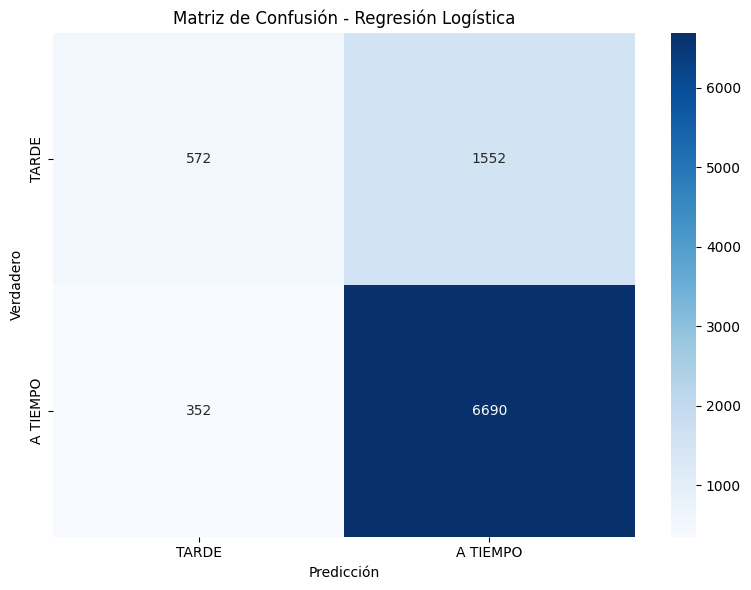

In [20]:
# 1. Generar predicciones
y_pred = logistic_reg.predict(X_test_norm)

# 2. Calcular la matriz FORZANDO el orden de las etiquetas
# Usamos labels=[1, 0] porque el LabelEncoder asignó A TIEMPO=0 y TARDE=1
# Al poner [1, 0], la matriz pondrá 'TARDE' en la primera fila/columna
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

# 3. Visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['TARDE', 'A TIEMPO'], 
            yticklabels=['TARDE', 'A TIEMPO'])

plt.title('Matriz de Confusión - Regresión Logística')
plt.ylabel('Verdadero')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

In [11]:
# Métricas por clase
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy (Exactitud):     {test_accuracy:.4f}")
print(f"Precision (Ponderada):    {precision:.4f}")
print(f"Recall (Exhaustividad):   {recall:.4f}")
print(f"F1-Score:                 {f1:.4f}")
print("=" * 60)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=le_estado.classes_))

Accuracy (Exactitud):     0.7923
Precision (Ponderada):    0.7671
Recall (Exhaustividad):   0.7923
F1-Score:                 0.7595

Reporte de Clasificación:
              precision    recall  f1-score   support

    A TIEMPO       0.81      0.95      0.88      7042
       TARDE       0.62      0.27      0.38      2124

    accuracy                           0.79      9166
   macro avg       0.72      0.61      0.63      9166
weighted avg       0.77      0.79      0.76      9166

